In [16]:
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import train_test_split
from sklearn import metrics

In [5]:
df = pd.read_csv("ejercicios_2/data/coches-de-segunda-mano-sample_procesado.csv")
df

,make,model,version,price,fuel,year,kms,power,doors,shift,color,is_professional,province
0,CITROEN,C1,CITROEN C1 PureTech 60KW 82CV Feel 5p.,6200,Gasolina,2017.0,50071,82.0,5,Manual,Blanco,True,Tenerife
1,FORD,Transit Connect,FORD Transit Connect Van 1.5 TDCi 100cv Ambien...,7851,Diésel,2016.0,103000,100.0,4,Manual,Blanco,True,Barcelona
2,VOLKSWAGEN,Caravelle,VOLKSWAGEN Caravelle Largo 2.0 TDI 140 Comfort...,19426,Diésel,2014.0,120000,140.0,4,Manual,Blanco,True,Navarra
3,FORD,Transit,FORD Transit 350 96kW L4 Ambiente Propulsion T...,22850,Diésel,2017.0,107000,130.0,2,Manual,Blanco,True,Sevilla
4,PEUGEOT,3008,PEUGEOT 3008 Style 1.2 PureTech 130 SS 5p.,11490,Gasolina,2016.0,78665,130.0,5,Manual,Blanco,True,Madrid
...,...,...,...,...,...,...,...,...,...,...,...,...,...
41240,HYUNDAI,i30,HYUNDAI i30 1.4 TGDI Tecno Fastback DCT 5p.,18490,Gasolina,2018.0,47000,140.0,5,Automático,Gris / Plata,True,Málaga
41241,RENAULT,Laguna,RENAULT Laguna Coupe Limited 2.0 Energy dCi 15...,14500,Diésel,2015.0,68750,150.0,2,Manual,KNG Gris Casiopea (metalizado),True,Málaga
41242,PEUGEOT,108,PEUGEOT 108 TOP Allure VTi 52kW 72CV 5p.,11000,Gasolina,2019.0,21422,72.0,5,Manual,Gris / Plata,True,Huelva
41243,AUDI,RS4,AUDI RS4 Avant 4.2 FSI 450cv quattro 5p.,47900,Gasolina,2013.0,47900,450.0,5,Automático,Gris / Plata (Antracita),True,Lugo


<Axes: >

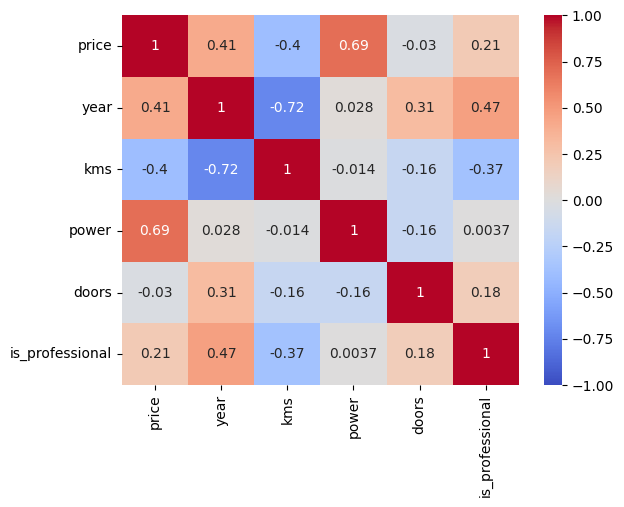

In [8]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", vmin=-1, vmax=1)

# X, y, train, test

In [9]:
X = df[["year", "kms", "power", "doors", "is_professional"]]
y = df["price"]

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=11)

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(32996, 5)
(32996,)
(8249, 5)
(8249,)


# LINEAR REGRESSION

In [17]:
lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

print('MAE:', metrics.mean_absolute_error(y_test, pred_lr))
print('MSE:', metrics.mean_squared_error(y_test, pred_lr))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, pred_lr)))
print('MAPE:', metrics.mean_absolute_percentage_error(y_test, pred_lr))
print("r2_score train", lr.score(X_train, y_train))
print("r2_score test",lr.score(X_test, y_test))

MAE: 4983.646912672643
MSE: 93912365.81755948
RMSE: 9690.839273125908
MAPE: 0.6075060869463149
r2_score train 0.6575800811234138
r2_score test 0.6782858337975577
